# Lipinski Rule of Five Drug-Likeness Analysis

## Project Objective

This project aims to determine which compounds satisfy Lipinski’s Rule of Five and to analyze how different physicochemical properties are related to drug-likeness.

This project uses a synthetic dataset for educational purposes.

## Background

Lipinski’s Rule of Five is a rule-based guideline used in early drug discovery to evaluate whether a compound is likely to have favorable oral drug-likeness properties.

The rule considers four main physicochemical properties:

- Molecular Weight ≤ 500
- LogP ≤ 5
- Hydrogen Bond Acceptors ≤ 10
- Hydrogen Bond Donors ≤ 5


## Dataset Description

The dataset contains 500 synthetic compounds generated for educational purposes. Each compound includes molecular descriptors commonly used in Lipinski’s Rule of Five analysis, including molecular weight, LogP, hydrogen bond acceptors, and hydrogen bond donors.


## Analysis Workflow

1. Create or load the dataset
2. Perform an initial data inspection
3. Check for missing values and duplicate records
4. Apply Lipinski’s Rule of Five
5. Calculate the number of rule violations
6. Conduct statistical analysis using summary statistics
7. Create visualizations
8. Write conclusions and key takeaways

## Setup

In this section, the required libraries are imported and basic settings are configured.


In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

np.random.seed(42)
data = {
    'Compound_ID': [f'Compound_{i}' for i in range(1, 501)],
    'Molecular_Weight': np.random.uniform(200, 800, 500),
    'LogP': np.random.uniform(-1, 7, 500),
    'H_Bond_Acceptors': np.random.randint(0, 15, 500),
    'H_Bond_Donors': np.random.randint(0, 8, 500)
}

df = pd.DataFrame(data)
#For reuse purposes
df.to_csv('drug_data.csv', index=False)




## Display dataset structure including columns,dtypes,and non-null values

In [55]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Compound_ID       500 non-null    object 
 1   Molecular_Weight  500 non-null    float64
 2   LogP              500 non-null    float64
 3   H_Bond_Acceptors  500 non-null    int32  
 4   H_Bond_Donors     500 non-null    int32  
dtypes: float64(2), int32(2), object(1)
memory usage: 15.8+ KB


,Compound_ID,Molecular_Weight,LogP,H_Bond_Acceptors,H_Bond_Donors
0,Compound_1,424.724071,4.585294,14,7
1,Compound_2,770.428584,3.288771,11,1
2,Compound_3,639.196365,1.476221,13,5
3,Compound_4,559.195091,5.510360,7,6
4,Compound_5,293.611184,4.477849,2,6


## Data Quality Checks (QC)

Goal: Verify missing values, duplicates, data types, and plausible numeric ranges before applying Lipinski rules.

In [56]:
print(f'Number of Missing Values: \n{df.isna().sum()}')

Number of Missing Values: 
Compound_ID         0
Molecular_Weight    0
LogP                0
H_Bond_Acceptors    0
H_Bond_Donors       0
dtype: int64


In [57]:
print(f"Number of duplicated rows: {df.duplicated().sum()}")
print(f"Number of duplicated Compound_ID values: {df.duplicated(subset=['Compound_ID']).sum()}")

Number of duplicated rows: 0
Number of duplicated Compound_ID values: 0


In [58]:
def QC(df,numeric_col,int_nonneg_col=()):
    report={}
    report['non_numeric']=[c for c in numeric_col if not pd.api.types.is_numeric_dtype(df[c])]
    before = df[numeric_col].copy()
    for c in numeric_col:
        df[c]=pd.to_numeric(df[c],errors='coerce')
    report['new_nans_after_coerce']=(df[numeric_col].isna() & before.notna()).sum().to_dict()
    for c in int_nonneg_col:
        s=df[c]
        report[f'{c}_negatives']=int((s < 0).sum(skipna=True))
        report[f'{c}_non_integer_like'] = int(((s % 1 != 0) & s.notna()).sum())
    return df, report
numeric_col=['Molecular_Weight','LogP','H_Bond_Acceptors','H_Bond_Donors']
df, rep = QC(df, numeric_col, int_nonneg_col=('H_Bond_Acceptors','H_Bond_Donors'))   
rep

{'non_numeric': [],
 'new_nans_after_coerce': {'Molecular_Weight': 0,
  'LogP': 0,
  'H_Bond_Acceptors': 0,
  'H_Bond_Donors': 0},
 'H_Bond_Acceptors_negatives': 0,
 'H_Bond_Acceptors_non_integer_like': 0,
 'H_Bond_Donors_negatives': 0,
 'H_Bond_Donors_non_integer_like': 0}

In [59]:
expected_ranges = {
    'Molecular_Weight':(200, 800),
    'LogP':(-1, 7),
    'H_Bond_Acceptors':(0, 14),
    'H_Bond_Donors':(0, 7)
}
def range_check(df):
    report={}
    for col,(min_value,max_value) in expected_ranges.items():
        report[col]={'out_of_range_count':int((~df[col].between(min_value,max_value)).sum()),
                     'min_observed':df[col].min(),
                     'max_observed':df[col].max(),
                     'expected_max':max_value,
                     'expected_min':min_value
                    }
                     
            
    return report
result=range_check(df)
report_df=pd.DataFrame(result).T
report_df[['min_observed', 'max_observed']] = report_df[['min_observed', 'max_observed']].round(3)

report_df

,out_of_range_count,min_observed,max_observed,expected_max,expected_min
Molecular_Weight,0.0,203.037,795.779,800.0,200.0
LogP,0.0,-0.963,6.998,7.0,-1.0
H_Bond_Acceptors,0.0,0.000,14.000,14.0,0.0
H_Bond_Donors,0.0,0.000,7.000,7.0,0.0


## Data quality checks showed no missing values, duplicate records, or implausible out-of-range values. The dataset was considered suitable for downstream Lipinski rule-based filtering.

In [60]:
#selected_df = df.query('Molecular_Weight <= 500 and LogP <= 5 and H_Bond_Acceptors <= 10 and H_Bond_Donors <= 5')
#selected_df
lipinski_mask=(df['Molecular_Weight']<=500) & (df['LogP']<=5) & (df['H_Bond_Acceptors']<=10) & (df['H_Bond_Donors']<=5) 
lipinski_mask
violations = (
    (df['Molecular_Weight'] > 500).astype(int) +
    (df['LogP'] > 5).astype(int) +
    (df['H_Bond_Acceptors'] > 10).astype(int) +
    (df['H_Bond_Donors'] > 5).astype(int)
)

df['Lipinski_Violations'] = violations
df['Lipinski_Compliant'] = df['Lipinski_Violations'] == 0
df[['Molecular_Weight', 'LogP', 'H_Bond_Acceptors', 'H_Bond_Donors',
    'Lipinski_Violations', 'Lipinski_Compliant']].head()


,Molecular_Weight,LogP,H_Bond_Acceptors,H_Bond_Donors,Lipinski_Violations,Lipinski_Compliant
0,424.724071,4.585294,14,7,2,False
1,770.428584,3.288771,11,1,2,False
2,639.196365,1.476221,13,5,2,False
3,559.195091,5.510360,7,6,3,False
4,293.611184,4.477849,2,6,1,False


In [61]:
compliant = df['Lipinski_Compliant'].sum()
non_compliant = len(df) - compliant
non_compliant_perc=non_compliant/len(df)*100
compliant_perc=compliant/len(df)*100
compliant_report=pd.DataFrame({'number':[non_compliant,compliant],
             'percent':[non_compliant_perc,compliant_perc]},
             index=['non_compliant','compliant'])
number_of_violations=df['Lipinski_Violations'].value_counts().sort_index()
print(f'here is your compliant_report:\n{compliant_report}\n\n')
print(f'number of violations:\n{number_of_violations}')

here is your compliant_report:
               number  percent
non_compliant     409     81.8
compliant          91     18.2


number of violations:
Lipinski_Violations
0     91
1    219
2    151
3     37
4      2
Name: count, dtype: int64


In [62]:
mw_violations = int((df['Molecular_Weight'] > 500).sum())
logp_violations = int((df['LogP'] > 5).sum())
hba_violations = int((df['H_Bond_Acceptors'] > 10).sum())
hbd_violations = int((df['H_Bond_Donors'] > 5).sum())
violations_number=pd.DataFrame({'mw_violations':mw_violations,
                'logp_violations':logp_violations ,
                'hba_violations': hba_violations,
                'hbd_violations':hbd_violations},index=['row'])
print(f'factor with most violation: {violations_number.idxmax(axis=1)}')
violations_number

factor with most violation: row    mw_violations
dtype: object


,mw_violations,logp_violations,hba_violations,hbd_violations
row,259,112,151,118


### Data Visualisation

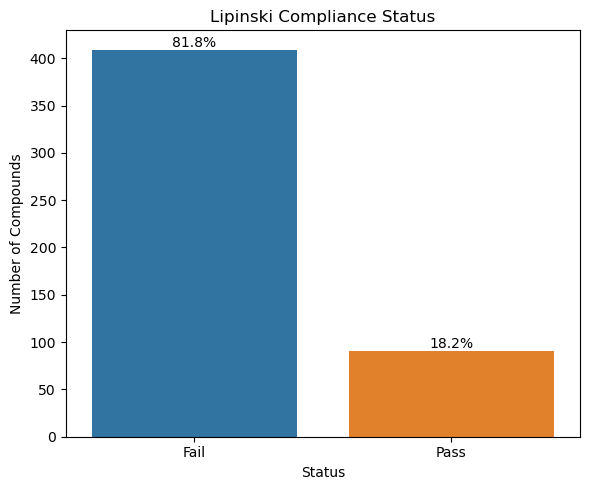

In [63]:

plt.figure(figsize=(6,5))
df['Status'] = df['Lipinski_Compliant'].map({
    True: 'Pass',
    False: 'Fail'
})
ax = sns.countplot(
    data=df,
    x='Status',
    hue='Status',
    legend=False
)

total = len(df)

for p in ax.patches:
    height = p.get_height()
    percent = 100 * height / total
    
    ax.annotate(
        f'{percent:.1f}%',
        (p.get_x() + p.get_width() / 2, height),
        ha='center',
        va='bottom'
    )

plt.title('Lipinski Compliance Status')
plt.xlabel('Status')
plt.ylabel('Number of Compounds')
plt.tight_layout()
plt.savefig('lipinski_status_count.png', dpi=300)
plt.show()


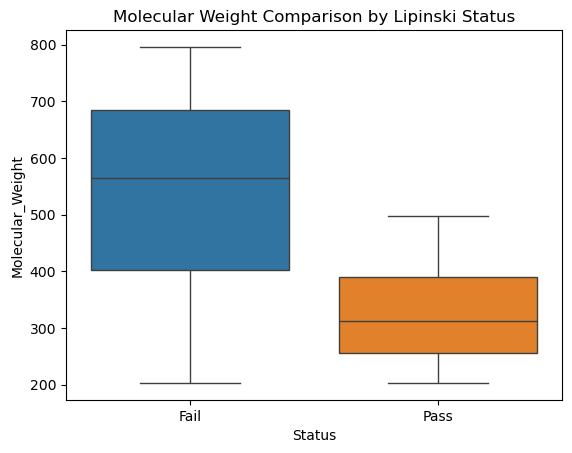

In [64]:
sns.boxplot(data=df,x='Status',y='Molecular_Weight',hue='Status')
plt.title('Molecular Weight Comparison by Lipinski Status')
plt.savefig('mw_boxplot_by_status.png', dpi=300)
plt.show()


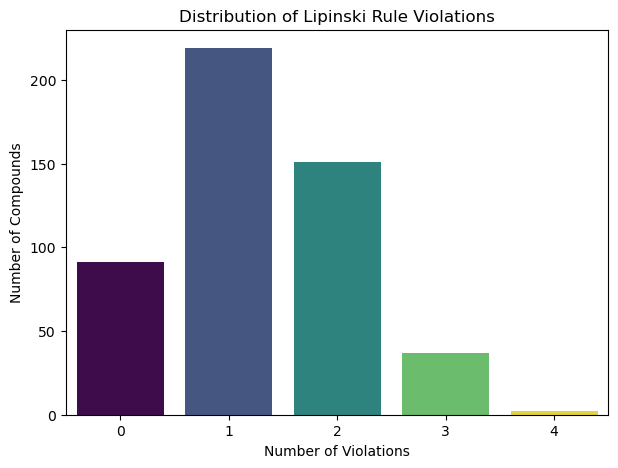

In [65]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=df,
    x='Lipinski_Violations',
    hue='Lipinski_Violations',
    palette='viridis',
    legend=False
)

plt.title('Distribution of Lipinski Rule Violations')
plt.xlabel('Number of Violations')
plt.ylabel('Number of Compounds')
plt.savefig('lipinski_violations_distribution.png', dpi=300)
plt.show()


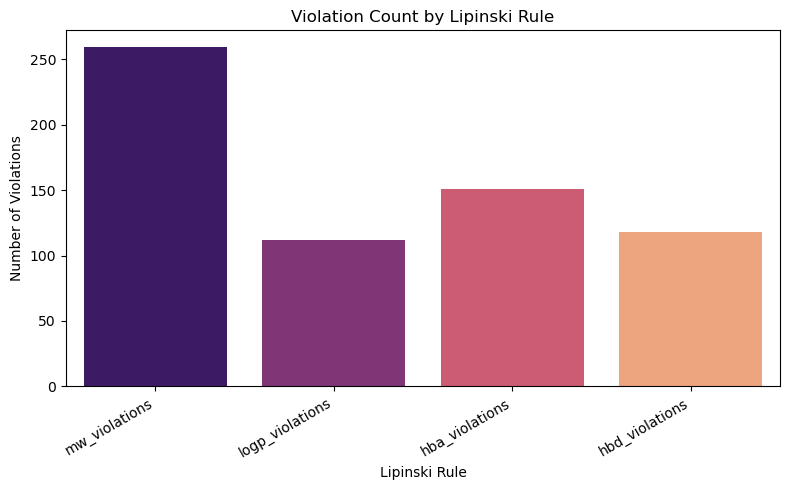

In [66]:
plot_df = violations_number.loc['row'].reset_index()

plot_df.columns = ['Rule', 'Violation_Count']

plt.figure(figsize=(8,5))

sns.barplot(
    data=plot_df,
    x='Rule',
    y='Violation_Count',
    hue='Rule',
    palette='magma',
    legend=False
)

plt.title('Violation Count by Lipinski Rule')
plt.xlabel('Lipinski Rule')
plt.ylabel('Number of Violations')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('rule_level_violations.png', dpi=300)
plt.show()



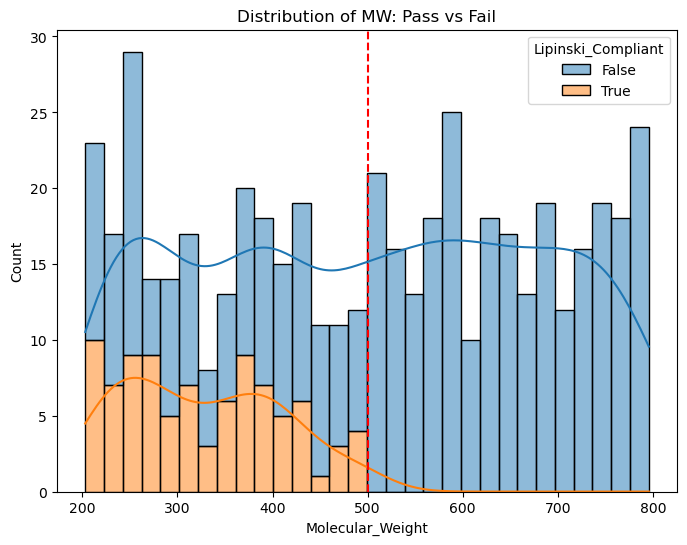

In [67]:
plt.figure(figsize=(8,6))
sns.histplot(data=df,x='Molecular_Weight',hue='Lipinski_Compliant',bins=30,kde=True,multiple='stack')
plt.title('Distribution of MW: Pass vs Fail')
plt.savefig('Distribution of MW: Pass vs Fail.png', dpi=300)
plt.axvline(500, color='red', linestyle='--', label='MW Limit')
plt.show()

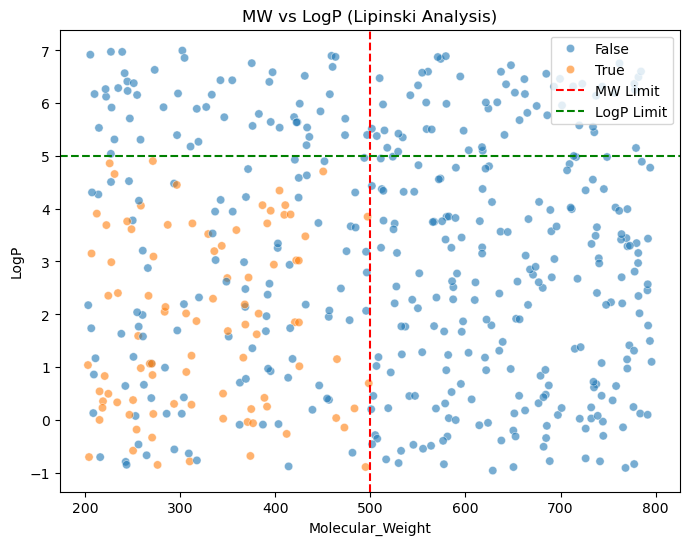

In [68]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df,x='Molecular_Weight',y='LogP',hue='Lipinski_Compliant',alpha=0.6)
plt.title('MW vs LogP (Lipinski Analysis)')
plt.axvline(500, color='red', linestyle='--', label='MW Limit')
plt.axhline(5, color='green', linestyle='--', label='LogP Limit')
plt.legend()
plt.savefig('mw_vs_logp.png', dpi=300)
plt.show()

### Failure reasons among compounds with acceptable MW and LogP

In [69]:
failed_right_MwL = df.query(
    "Molecular_Weight <= 500 and LogP <= 5 and Lipinski_Compliant == False"
)

HBA_failure = (
    (failed_right_MwL['H_Bond_Acceptors'] > 10) &
    (failed_right_MwL['H_Bond_Donors'] <= 5)
).sum()

HBD_failure = (
    (failed_right_MwL['H_Bond_Donors'] > 5) &
    (failed_right_MwL['H_Bond_Acceptors'] <= 10)
).sum()

HBDA_failure = (
    (failed_right_MwL['H_Bond_Donors'] > 5) &
    (failed_right_MwL['H_Bond_Acceptors'] > 10)
).sum()

nothing_failed = (
    (failed_right_MwL['H_Bond_Donors'] <= 5) &
    (failed_right_MwL['H_Bond_Acceptors'] <= 10)
).sum()

total_num = len(failed_right_MwL)

if total_num > 0:
    report = pd.DataFrame({
        'count': [
            HBA_failure,
            HBD_failure,
            HBDA_failure,
            nothing_failed
        ],
        'percent': [
            HBA_failure / total_num * 100,
            HBD_failure / total_num * 100,
            HBDA_failure / total_num * 100,
            nothing_failed / total_num * 100
        ]
    })

    report.index = [
        'HBA>10 only (HBD<=5)',
        'HBD>5 only (HBA<=10)',
        'Both HBA>10 & HBD>5',
        'Neither (HBA<=10 & HBD<=5)'
    ]

    report['percent'] = report['percent'].round(2)
    report.to_csv('mw_logp_fail_reasons_report.csv')

    print(report)
    print("Percent sum:", report['percent'].sum())

else:
    print("No failed compounds found among compounds with acceptable MW and LogP.")
    report = pd.DataFrame()


                            count  percent
HBA>10 only (HBD<=5)           42    44.21
HBD>5 only (HBA<=10)           42    44.21
Both HBA>10 & HBD>5            11    11.58
Neither (HBA<=10 & HBD<=5)      0     0.00
Percent sum: 100.0


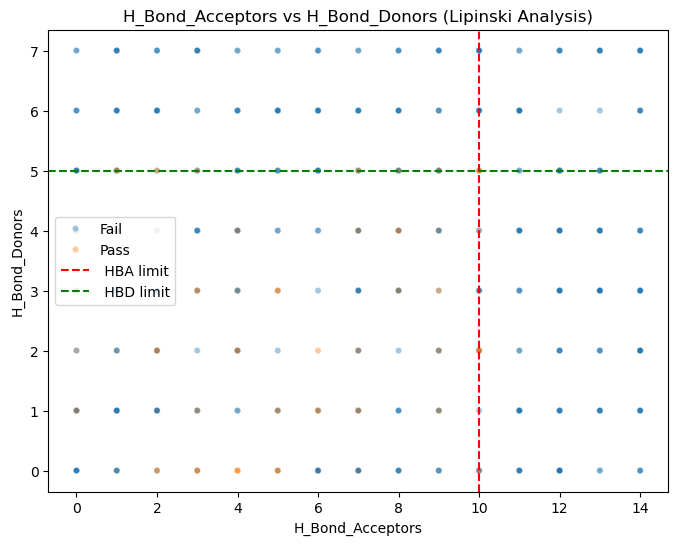

In [70]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df,x='H_Bond_Acceptors',y='H_Bond_Donors',hue='Status',alpha=0.4,s=20)
plt.title('H_Bond_Acceptors vs H_Bond_Donors (Lipinski Analysis)')
plt.axvline(10, color='red', linestyle='--', label=' HBA limit')
plt.axhline(5, color='green', linestyle='--', label=' HBD limit')
plt.legend()
plt.savefig('H_Bond_Acceptors vs H_Bond_Donors.png', dpi=300)
plt.show()

### Key Findings
The dataset was analyzed using Lipinski’s Rule of Five to evaluate the drug‑likeness of the compounds. Each compound was examined for violations of the four core physicochemical criteria: molecular weight (MW), lipophilicity (LogP), hydrogen bond acceptors (HBA), and hydrogen bond donors (HBD).

Compounds with zero violations were classified as Lipinski‑compliant, while compounds with one or more violations were considered non‑compliant. The analysis showed that most compounds fall within acceptable ranges for several properties, but specific parameters contributed more frequently to rule violations.

Molecular weight and LogP are major physicochemical indicators of oral bioavailability, and several compounds exceeded these thresholds. Additionally, some compounds remained non‑compliant despite having acceptable MW and LogP values, primarily due to elevated numbers of hydrogen bond acceptors or donors.

The distribution of violations highlights which physicochemical constraints most strongly influence drug‑likeness in this dataset. Visual exploration of MW, LogP, HBA, and HBD further clarifies the separation between compliant and non‑compliant compounds and provides insight into the structural characteristics associated with Lipinski rule violations.

In [71]:
summary_report = df.groupby('Status')[
    ['Molecular_Weight', 'LogP', 'H_Bond_Acceptors', 'H_Bond_Donors']
].mean().round(2)

status_summary = df['Status'].value_counts().rename_axis('Status').reset_index(name='Count')
status_summary['Percentage'] = (status_summary['Count'] / len(df) * 100).round(2)

display(summary_report)
display(status_summary)


,Molecular_Weight,LogP,H_Bond_Acceptors,H_Bond_Donors
Status,,,,
Fail,537.64,3.09,7.74,3.62
Pass,326.08,1.82,5.54,2.49


,Status,Count,Percentage
0,Fail,409,81.8
1,Pass,91,18.2


## Conclusion

In this project, the compounds in the dataset were evaluated using Lipinski's Rule of Five. Four key physicochemical properties were assessed for each compound: molecular weight, LogP, hydrogen bond acceptors, and hydrogen bond donors. The number of rule violations was calculated for each compound, and compounds with zero violations were classified as Lipinski-compliant.

The results indicate that Lipinski-compliant compounds generally have lower average molecular weight, LogP, hydrogen bond acceptor count, and hydrogen bond donor count compared with non-compliant compounds. This observation is consistent with the rationale behind Lipinski's Rule of Five, as excessive molecular size, lipophilicity, or hydrogen bonding capacity may reduce the likelihood of favorable oral bioavailability.

The compliance summary further showed that only a subset of the dataset satisfied all Lipinski criteria without any violations. Overall, this analysis provides a clear and interpretable workflow for identifying compounds with more favorable drug-like physicochemical profiles and for prioritizing candidates in early-stage drug discovery.


In [72]:
passed_drugs = df.loc[df['Status'] == 'Pass', :]
passed_drugs.to_csv('passed_drugs.csv', index=False)
df.to_csv('lipinski_labeled.csv', index=False)
status_summary.to_csv('lipinski_status_summary.csv', index=False)
summary_report.to_csv('lipinski_property_means.csv')

## final output
lipinski_labeled.csv → dataset with Lipinski compliance labels
passed_drugs.csv → compounds that satisfy Lipinski rule of five
status_summary → Shows the count and percentage of compounds that pass or fail Lipinski’s Rule of Five.
summary_report → Shows the average (mean) values of the physicochemical properties for Pass and Fail compounds.